# Variational Autoencoder with 3D Latent Space

Same VAE recipe as `02_VAE_2D.ipynb` but with `z_dim = 3`. Compares against the
plain AE from `01_FC_Autoencoder_3D.ipynb`.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
bs = 100
train_dataset = datasets.FashionMNIST(root="./data/", train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root="./data/", train=False, download=True, transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=bs, shuffle=False)
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 60000, Test: 10000


## 1. Model

In [3]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super().__init__()
        # encoder part
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)
        self.fc32 = nn.Linear(h_dim2, z_dim)
        # decoder part
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)

    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h)  # mu, log_var

    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu)

    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return torch.sigmoid(self.fc6(h))

    def forward(self, x):
        mu, log_var = self.encoder(x.view(-1, 784))
        z = self.sampling(mu, log_var)
        return self.decoder(z), mu, log_var


vae = VAE(x_dim=784, h_dim1=512, h_dim2=256, z_dim=3).to(device)
print(vae)

VAE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc31): Linear(in_features=256, out_features=3, bias=True)
  (fc32): Linear(in_features=256, out_features=3, bias=True)
  (fc4): Linear(in_features=3, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=512, bias=True)
  (fc6): Linear(in_features=512, out_features=784, bias=True)
)


## 2. Loss and Optimizer

In [4]:
optimizer = optim.Adam(vae.parameters())

def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction="sum")
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

## 3. Training

In [5]:
def train(epoch):
    vae.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        recon_batch, mu, log_var = vae(data)
        loss = loss_function(recon_batch, data, mu, log_var)

        loss.backward()
        train_loss += loss.item()
        optimizer.step()

        if batch_idx % 100 == 0:
            print("Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item() / len(data)))
    print("====> Epoch: {} Average loss: {:.4f}".format(epoch, train_loss / len(train_loader.dataset)))


def test():
    vae.eval()
    test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            recon, mu, log_var = vae(data)
            test_loss += loss_function(recon, data, mu, log_var).item()
    test_loss /= len(test_loader.dataset)
    print("====> Test set loss: {:.4f}".format(test_loss))

In [6]:
for epoch in range(1, 11):
    train(epoch)
    test()

torch.save(vae.state_dict(), "fc_vae_3d.pth")
print("Saved fc_vae_3d.pth")

Train Epoch: 1 [0/60000 (0%)]	Loss: 544.954727
Train Epoch: 1 [10000/60000 (17%)]	Loss: 307.388809
Train Epoch: 1 [20000/60000 (33%)]	Loss: 280.898633
Train Epoch: 1 [30000/60000 (50%)]	Loss: 258.238105
Train Epoch: 1 [40000/60000 (67%)]	Loss: 261.283906
Train Epoch: 1 [50000/60000 (83%)]	Loss: 260.241543
====> Epoch: 1 Average loss: 281.3831
====> Test set loss: 259.4626
Train Epoch: 2 [0/60000 (0%)]	Loss: 252.026738
Train Epoch: 2 [10000/60000 (17%)]	Loss: 263.333125
Train Epoch: 2 [20000/60000 (33%)]	Loss: 246.764941
Train Epoch: 2 [30000/60000 (50%)]	Loss: 246.558086
Train Epoch: 2 [40000/60000 (67%)]	Loss: 259.408516
Train Epoch: 2 [50000/60000 (83%)]	Loss: 247.570410
====> Epoch: 2 Average loss: 256.1372
====> Test set loss: 255.9404
Train Epoch: 3 [0/60000 (0%)]	Loss: 254.181504
Train Epoch: 3 [10000/60000 (17%)]	Loss: 242.917969
Train Epoch: 3 [20000/60000 (33%)]	Loss: 253.500781
Train Epoch: 3 [30000/60000 (50%)]	Loss: 264.481973
Train Epoch: 3 [40000/60000 (67%)]	Loss: 259.41

## 4. Reconstruction Quality

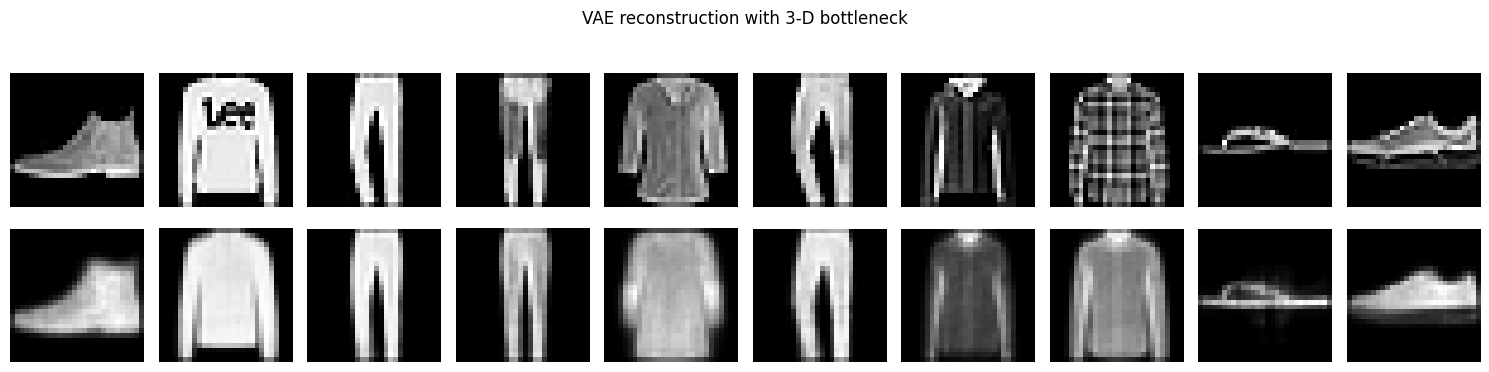

In [7]:
vae.eval()
data, _ = next(iter(test_loader))
data = data[:10].to(device)
with torch.no_grad():
    recon, _, _ = vae(data)
recon = recon.view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(data[i].cpu().squeeze(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].cpu().squeeze(), cmap="gray"); axes[1, i].axis("off")

plt.suptitle("VAE reconstruction with 3-D bottleneck", fontsize=12)
plt.tight_layout()
plt.show()

## 5. The 3D Latent Space

Encode the entire test set and plot the encoder means $\mu$ in 3D.

In [8]:
all_mu, all_labels = [], []
with torch.no_grad():
    for data, labels in test_loader:
        mu, _ = vae.encoder(data.to(device).view(-1, 784))
        all_mu.append(mu.cpu()); all_labels.append(labels)
all_mu = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

for i in range(3):
    print(f"mu_{i+1}: range [{all_mu[:, i].min():.2f}, {all_mu[:, i].max():.2f}], "
          f"mean={all_mu[:, i].mean():.2f}, std={all_mu[:, i].std():.2f}")

mu_1: range [-3.63, 2.67], mean=0.08, std=1.02
mu_2: range [-3.60, 3.94], mean=0.10, std=1.04
mu_3: range [-2.41, 2.36], mean=0.12, std=1.09


## 6. Side-by-Side: AE vs VAE Latent Space

Load the AE latents from `01_FC_Autoencoder_3D.ipynb` and plot both clouds with
the same axis limits so the difference in scale and shape is obvious.

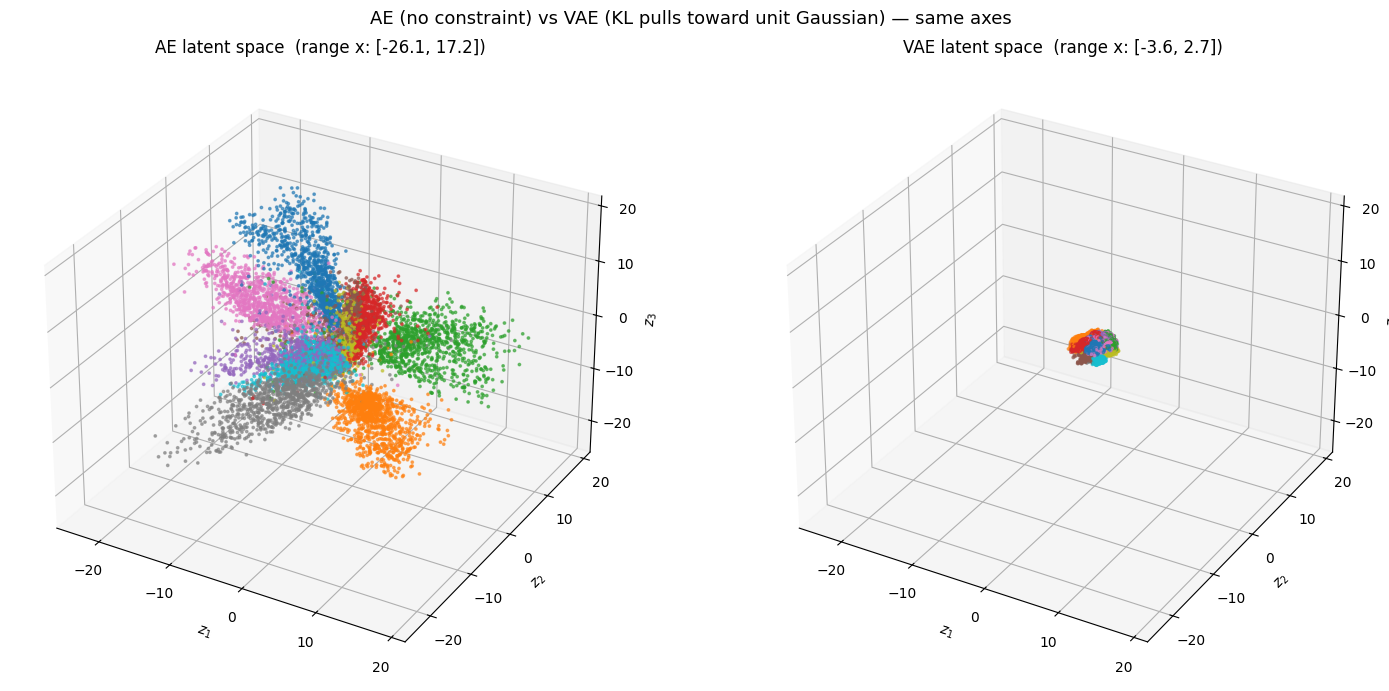

In [9]:
ae_data = np.load("latents_ae_3d.npz")
ae_z = ae_data["z"]
ae_labels = ae_data["labels"]

all_pts = np.vstack([ae_z, all_mu])
lo, hi = all_pts.min(), all_pts.max()

fig = plt.figure(figsize=(15, 7))
for k, (pts, labels, title) in enumerate(
    [(ae_z, ae_labels, "AE"), (all_mu, all_labels, "VAE")]
):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    sc = ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                    c=labels, cmap="tab10", s=3, alpha=0.6)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_zlim(lo, hi)
    ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
    ax.set_title(f"{title} latent space  (range x: [{pts[:,0].min():.1f}, {pts[:,0].max():.1f}])")
fig.suptitle("AE (no constraint) vs VAE (KL pulls toward unit Gaussian) — same axes", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Sampling: $z \sim \mathcal{N}(0, I)$

Run the same Gaussian samples through both decoders.

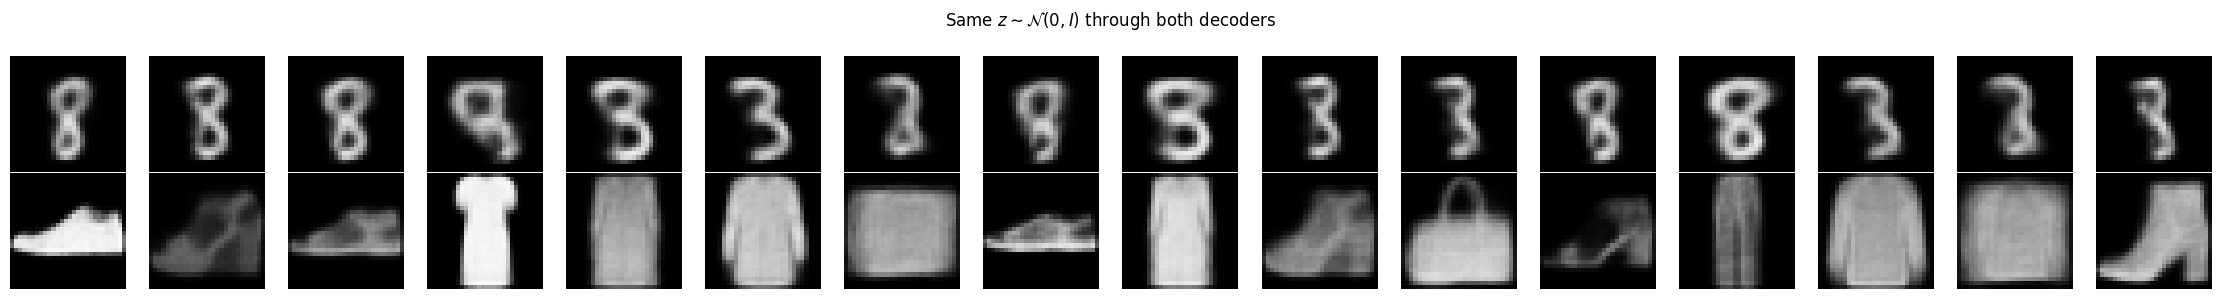

In [10]:
# Reload the AE for the side-by-side decoder comparison
class FCAutoencoder(nn.Module):
    def __init__(self, latent_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 28 * 28), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z).view(-1, 1, 28, 28), z

ae = FCAutoencoder(3).to(device)
ae.load_state_dict(torch.load("fc_autoencoder_3d.pth", map_location=device))
ae.eval()

torch.manual_seed(0)
N = 16
z = torch.randn(N, 3, device=device)
with torch.no_grad():
    ae_samples = ae.decoder(z).view(-1, 28, 28).cpu()
    vae_samples = vae.decoder(z).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(2, N, figsize=(1.4 * N, 3))
for j in range(N):
    axes[0, j].imshow(ae_samples[j], cmap="gray", vmin=0, vmax=1); axes[0, j].axis("off")
    axes[1, j].imshow(vae_samples[j], cmap="gray", vmin=0, vmax=1); axes[1, j].axis("off")

fig.suptitle("Same $z \\sim \\mathcal{N}(0, I)$ through both decoders", fontsize=12)
plt.tight_layout()
plt.show()